# Agent的上下文工程

## overview 

在构建 Agent 或者 任何LLM应用的时候，难点一般在于使其足够可靠。虽然一些应用在原型的时候可以正常工作，但是经常会在真实使用中失败

为什么 Agent 会任务失败？

当 Agent 任务失败时，通常是因为Agent内部的LLM调用采取了错误的行为，没有按照预期的去做。 LLM 失败的原因来两种：
1. 底层LLM能力不足
2. 没有传递正确的 上下文 给LLM

一般来说都是第二个惹的祸，导致Agent变得不可靠

上下文工程（Context Engineering）就是 为 `LLM` 提供正确的 **信息、工具，并且按照正确的格式完成任务** 的 **上下文**。 “正确”的上下文是Agent变得更加可靠的首要任务，Langchain的Agent抽象设计，为了促进上下文工程



## Context 是什么？

> 关于上下文的相关概念

上下文工程是构建动态系统的实践，这些系统能够提供 **合适的信息** 和 **工具** ，以正确的 **格式** ，使 AI 应用能够完成任务。上下文可以通过两个关键维度来描述，一个是可变性、一个是按照生命周期



1. 可变性
   - Static Context：静态上下文，在执行期间不变的数据，比如说用户元数据、数据库连接、工具
   - Dynamic Context：动态上下文，在执行期间不断变化的数据，比如说对话历史记录、中间结果、工具调用观察结果
2. 生命周期
   - Runtime Context：运行时上下文，仅限在单个运行或调用期间存在的
   - Cross-conversation：跨对话上下文，在多个对话中持续存在的数据

> 运行时上下文（Runtime Context）指的是本地的上下文，也就是代码运行时所需的数据和依赖项，运行时上下文不是指：
> 1. LLM 的上下文、也就是传递给大模型的所有提示数据（消息列表、skills、mcp等等数据）
> 2. 上下文窗口，也就是可以传递给模型的最大tokens数量
>
> Runtime Context 是一种依赖注入形式，可以用于优化传入给LLM的上下文。它允许在运行时而不是硬编码的方式向 工具 和 节点 提供依赖项（比如说数据库连接、用户ID），可以使用运行时上下文中的用户元数据来获取用户偏好，并且将他们写入LLM的上下文窗口


langgraph提供了三种管理上下文的方式，结合了可变性和生命周期两个维度

| Context type 上下文类型 | Description 描述 | Mutability 可变性 | Lifetime 生命周期 | Access method 访问方法 |
| --- | --- | --- | --- | --- |
| [**Static runtime context 静态运行时上下文**](https://docs.langchain.com/oss/python/concepts/context#static-runtime-context) | User metadata, tools, db connections passed at startup   在启动时传递的用户元数据、工具、数据库连接 | Static 静态 | Single run 单次运行 |   传入 `context` 参数到 `invoke` / `stream` |
| [**Dynamic runtime context (state)   动态运行时上下文（状态）**](https://docs.langchain.com/oss/python/concepts/context#dynamic-runtime-context-state) | Mutable data that evolves during a single run   在单次运行期间演变的可变数据 | Dynamic 动态 | Single run 单次运行 | LangGraph state object LangGraph 状态对象 |
| [**Dynamic cross-conversation context (store)   动态跨对话上下文（存储）**](https://docs.langchain.com/oss/python/concepts/context#dynamic-cross-conversation-context-store) | Persistent data shared across conversations   跨对话持久共享数据 | Dynamic 动态 | Cross-conversation 跨对话 | LangGraph store LangGraph 存储 |


【一句话来说】

> langgraph里面有三种管理上下文的方式，一种是静态的上下文，在启动时传递用户元数据、工具、数据库连接，这些在单次运行期间是不会变化的，通过 context 参数传递给 invoke / stream；第二种是单次运行的State（状态），在单次运行期间可变的数据，比如说消息列表，或者自定义的字段（权限变化）；第三种是跨对话的Store，跨对话持久共享数据。

### Static Runtime Context

静态运行时上下文代表不可变数据，如用户元数据、工具和数据库连接，这些数据通过 context 参数在运行开始时传递给应用程序 / invoke / stream 。这些数据在执行过程中不会改变。

我们可以通过 `@dataclass`、Pydantic、TypedDict 来定义 Context 的格式

### Dynamic Runtime Context -- State

动态运行时上下文表示在单次运行期间可以演变的可变数据，并通过 **LangGraph State** 对象进行管理。这包括 **对话历史记录、中间结果以及从工具或 LLM 输出中派生的值** 。在 LangGraph 中，State 对象在运行期间充当短期记忆。 State -> 短期记忆

State也可以被Agent的Tools访问，这些Tools可以根据需要访问和修改State中的数据

In [1]:

# ? 在 Agent 中使用 State
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest
from langchain.agents import AgentState

In [2]:
from langchain_openai import ChatOpenAI
import os
def get_model():
    """获取聊天模型实例"""
    return ChatOpenAI(
        model="Qwen/Qwen2.5-7B-Instruct",
        base_url="https://api.siliconflow.cn/v1",
        api_key=os.environ.get("SILICONFLOW_API_KEY"),
        temperature=0.2,
    )
llm = get_model()
llm

ChatOpenAI(profile={}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000014C49B0B450>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000014C4A04A490>, root_client=<openai.OpenAI object at 0x0000014C49A6AC10>, root_async_client=<openai.AsyncOpenAI object at 0x0000014C4A049890>, model_name='Qwen/Qwen2.5-7B-Instruct', temperature=0.2, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://api.siliconflow.cn/v1')

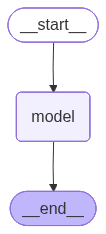

In [ ]:
# 定义 Context Schema
# 通过继承AgentState类，我们可以定义一个自定义的AgentState类，用于存储自定义的上下文信息

class CustomAgentState(AgentState):
    user_name: str

@dynamic_prompt
def personalized_prompt(request: ModelRequest) -> str:
    #? 从 request.state 中获取 user_name 然后组装到系统提示词里
    user_name = request.state.get("user_name", "User")
    return f"你服务的人叫做：{user_name}！"

agent = create_agent(
    model=llm,
    tools=[],
    state_schema=CustomAgentState,      # 这个Agent的State格式
    middleware=[personalized_prompt],
)
agent

In [6]:
agent.invoke({
    "messages": "你好",
    "user_name": "Chasen"
})["messages"][-1].content

'你好！很高兴为你提供帮助，Chasen。你需要了解或解决些什么问题呢？'

### Dynamic cross-conversation context -- Store

动态跨对话上下文代表持久且可变的数据，这些数据跨越多个对话或会话，并通过 LangGraph Store 进行管理。这包括用户资料、偏好和历史交互。LangGraph Store 充当跨多次运行的 **长时记忆** 。这可用于读取或更新持久事实（例如，用户资料、偏好、先前的交互）。

## The Agent Loop
典型的 Agent Loop 主要包括两个步骤组成：
1. Model Call：调用模型，使用提示词或者工具调用 LLM，返回响应或工具的请求
2. Tool Execution：执行LLM请求的工具，返回工具的响应

这个循环会一直持续，直到LLM决定结束

## 什么是可以控制的？
为了构建可靠的Agent系统，需要控制Agent Loop 的每一步以及步骤之间的发生情况

首先来看可控制的Context类型：

- Model Context：模型上下文，可以控制模型调用中包含什么，指令、历史消息、工具、响应格式。这个上下文是瞬时性的，也就是在调用模型的时候传递给模型的数据
- Tool Context：工具上下文，可以控制哪些工具可以访问和产生，读取或写入State、Store、Runtime Context。这个变化是持久化的
- Life-cycle Context：生命周期上下文，可以控制模型和工具调用之间会发生什么，比如说摘要、护栏、日志记录等等；它让你能够在智能体运行的不同阶段插入自定义逻辑，通过中间件来实现

【瞬时上下文和持久上下文？】
- 瞬时：一个调用中大模型看到的内容，可以修改信息、工具或提示，而不需要修改保存的State
- 持久：跨回合保存的内容，生命周期钩子和工具写入会永久修改此内容

## 数据源（Data Sources）
在此过程中，Agent可访问（读写）的数据源包括：
- Runtime Context：运行时上下文也叫做 **静态配置** ，在对话范围内一直存在且不会改变；比如说用户ID、API密钥、数据库连接、权限、环境设置
- State：也叫做短期记忆，在对话范围内存在但是可以改变；比如说当前消息、上传的文件、认证状态、工具结果等
- Store：也叫做长期记忆，可以跨对话存在；比如说用户的偏好、提取的洞察、记忆、历史数据等


## 工作原理
Langchain的 `Middleware` 是使得 Langchain 的开发者能够实现上下文工程的技术机制

中间件允许钩入Agent的生命周期中的任何步骤，并且：
- 更新上下文
- 跳转到Agent生命周期的不同步骤

使用中间件是最频繁的作为Context Engineering的一种手段

## Model Context

可以控制每次模型调用中输入的内容 --> 指令、可用工具、使用哪个模型以及输出格式。这些决策直接影响了可靠性和成本

模型上下文囊括的内容有:

- System Prompt：开发者向LLM设定的 **基础指令** ，用于引导模型的行为
- Messages：发送给LLM的完整消息列表
- Tools：Agent可以访问以 **执行操作** 的工具。
- Model：实际调用的模型，包括配置
- Response Format：模型最终响应的Schema（模式/格式）

这些所有类型的模型上下文都可以从State（短期）、Store（长期）或者Runtime Context（静态配置）中获取

【扩展：Schema应该翻译成什么？】
Schema（模式）是用于定义Format（格式）的工具。格式是数据呈现或组织的方式、布局或约定。例如，JSON格式、XML格式、CSV格式等。Schema是数据结构的正式定义，包括字段名称、类型、约束和描述。

| 概念 | 英文 | 中文翻译 | 核心含义 | 在文档中的体现 |
| --- | --- | --- | --- | --- |
| Format | Format | 格式 | 数据呈现或组织的方式、布局或约定。 | 章节标题“Response format”指的是模型输出的整体形式要求。 |
| Schema | Schema | 模式、架构、纲要 | 数据结构的正式定义，包括字段名称、类型、约束和描述。 | 代码中定义的CustomerSupportTicket类，用Field指定每个字段的描述，这就是一个Schema。 |



### System Prompt
系统提示设定了 LLM 的行为和能力。不同的用户、上下文或对话阶段需要不同的指令。成功的代理会参考记忆、偏好和配置，为当前对话状态提供正确的指令。



#### 访问State
从状态中访问消息计数或对话上下文的示例代码

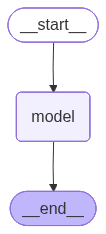

In [7]:
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest


#? 中间件传入的参数都是 request 和 handler
@dynamic_prompt
def state_aware_prompt(request: ModelRequest) -> str:
    # request.messages is a shortcut for request.state["messages"]
    message_count = len(request.messages)

    base = "You are a helpful assistant."

    if message_count > 10:
        base += "\nThis is a long conversation - be extra concise."

    return base

agent = create_agent(
    model=llm,
    tools=[],
    middleware=[state_aware_prompt]
)
agent 

#### 访问Store
从Store中访问用户偏好

In [8]:
from dataclasses import dataclass
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest
from langgraph.store.memory import InMemoryStore

# 定义一个Store的Schema

@dataclass
class Context:
    user_id: str
    user_name: str

#! 一般使用TypedDict来定义Store的Schema
# from typing import TypedDict
# class UserPreferences(TypedDict):
#     communication_style: str = "balanced"

@dynamic_prompt
def store_aware_prompt(request: ModelRequest) -> str:
    user_id = request.runtime.context.user_id 
    # 为了查询Store中的用户偏好，需要从Runtime中获取user_id

    # Read from Store: get user preferences
    store = request.runtime.store # 获取当前的Store
    user_prefs = store.get(("preferences",), user_id)
    # 获取命名空间("preferences",)下的user_id对应的值


    base = "You are a helpful assistant."

    if user_prefs:
        style = user_prefs.value.get("communication_style", "balanced")
        base += f"\nUser prefers {style} responses."

    return base

【扩展：request是个啥东东？？】

```python
@dataclass(init=False)
class ModelRequest(Generic[ContextT]):
    """Model request information for the agent.

    Type Parameters:
        ContextT: The type of the runtime context. Defaults to `None` if not specified.
    """

    model: BaseChatModel
    messages: list[AnyMessage]  # excluding system message
    system_message: SystemMessage | None
    tool_choice: Any | None
    tools: list[BaseTool | dict[str, Any]]
    response_format: ResponseFormat[Any] | None
    state: AgentState[Any]
    runtime: Runtime[ContextT]
    model_settings: dict[str, Any] = field(default_factory=dict)
```

ModelRequest是一个数据类，用于存储模型请求的信息。可以通过这个来在中间件中访问 State 和 Runtime 中的信息。

#### 访问Runtime Context

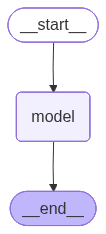

In [ ]:
from dataclasses import dataclass
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest

@dataclass
class Context:
    user_role: str
    deployment_env: str

@dynamic_prompt
def context_aware_prompt(request: ModelRequest) -> str:
    # Read from Runtime Context: user role and environment
    user_role = request.runtime.context.user_role
    env = request.runtime.context.deployment_env

    base = "You are a helpful assistant."

    if user_role == "admin":
        base += "\nYou have admin access. You can perform all operations."
    elif user_role == "viewer":
        base += "\nYou have read-only access. Guide users to read operations only."

    if env == "production":
        base += "\nBe extra careful with any data modifications."

    return base

agent = create_agent(
    model=llm,
    tools=[],
    middleware=[context_aware_prompt],
    context_schema=Context
)

agent

- State — 字典形式，整个运行周期的状态共享
- Store — 命名空间 + 键值对，跨会话持久化存储
- 运行时上下文（context） — 也是字典，用于传递临时信息

### Messages 消息
消息构成了发送给 LLM 的 **Prompt** 。管理消息内容至关重要，以确保 LLM 能够获得正确信息从而做出良好响应。

#### State
在当前查询中，从State中注入上传的文件的上下文


In [10]:
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable

@wrap_model_call # 包括模型调用时
def inject_file_context(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Inject context about files user has uploaded this session."""
    # 注入文件上下文到Prompt然后发送给LLM 
    # wrap_model_call
    # Read from State: get uploaded files metadata
    uploaded_files = request.state.get("uploaded_files", [])

    if uploaded_files:
        # Build context about available files
        file_descriptions = []
        for file in uploaded_files:
            file_descriptions.append(
                f"- {file['name']} ({file['type']}): {file['summary']}"
            )

        file_context = f"""Files you have access to in this conversation:
{chr(10).join(file_descriptions)}

Reference these files when answering questions."""

        # Inject file context before recent messages
        messages = [
            *request.messages,  # 本来的消息列表
            {"role": "user", "content": file_context}, # 注入文件上下文
        ]
        request = request.override(messages=messages)

    return handler(request)

agent = create_agent(
    model=llm,
    tools=[],
    middleware=[inject_file_context]
)